<a href="https://colab.research.google.com/github/deepakvarghesevm/case_study_of_unsupervised_deepak/blob/main/case_study_of_unsupervised_deepak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/b11datasciencecoursefolders/case_study_of_unsupervised_deepak/adult_dataset.csv')

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
for col in df.columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 10)

Unique values in 'age':
[ 39.  50.  38.  53.  28.  37.  49.  52.  31.  42.  30.  23.  32.  40.
  34.  25.  nan  54.  35.  43.  59.  56.  19.  20.  45.  22.  48.  21.
  24.  57.  44.  41.  29.  18.  47.  46.  79.  27.  67.  33.  76.  17.
 120.  36.  55.  61.  70.  64.  71.  68.  66.  51.  58.  26.  60.  90.
  75.  65.  77.  62.  63.  80.  74.  72.  69.  73.  81.  88. 250.  78.
  82.  83. 255.  84.  85. 225. 230.  86.  87.  89. 140. 100. 210.]
----------
Unique values in 'workclass':
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 '?' 'Self-emp-inc' 'Without-pay' 'Never-worked']
----------
Unique values in 'fnlwgt':
[ 77516  83311 215646 ... 173449  89686 350977]
----------
Unique values in 'education':
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
----------
Unique values in 'education-num':
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8

In [ ]:
df['workclass'] = df['workclass'].replace('?', np.nan)

In [ ]:
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Identify categorical/object columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

In [ ]:
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.
48839,38.0,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50.0,United-States,<=50K.
48840,44.0,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40.0,United-States,<=50K.


In [ ]:
outlier_cols = ['age', 'hours-per-week']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", lower_bound)
    print("Upper:", upper_bound)

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

age
Q1: 28.0
Q3: 47.0
IQR: 19.0
Lower: -0.5
Upper: 75.5
hours-per-week
Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower: 32.5
Upper: 52.5


In [ ]:
#  applying one hot encode for work class,education,occupation and native country
from sklearn.preprocessing import OneHotEncoder

onehotencoder = OneHotEncoder()
df_encoded = pd.DataFrame(onehotencoder.fit_transform(df[['workclass', 'education', 'occupation', 'native-country']]).toarray(),dtype = int)
df_encoded.columns = onehotencoder.get_feature_names_out(['workclass', 'education', 'occupation', 'native-country'])
df = pd.concat([df, df_encoded], axis=1)
df.drop(['workclass', 'education', 'occupation', 'native-country'], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
df['marital-status'] = labelencoder.fit_transform(df['marital-status'])
df['relationship'] = labelencoder.fit_transform(df['relationship'])
df['race'] = labelencoder.fit_transform(df['race'])
df['sex'] = labelencoder.fit_transform(df['sex'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 92 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        48842 non-null  float64
 1   fnlwgt                                     48842 non-null  int64  
 2   education-num                              48842 non-null  int64  
 3   marital-status                             48842 non-null  int64  
 4   relationship                               48842 non-null  int64  
 5   race                                       48842 non-null  int64  
 6   sex                                        48842 non-null  int64  
 7   capital-gain                               48842 non-null  int64  
 8   capital-loss                               48842 non-null  int64  
 9   hours-per-week                             48842 non-null  float64
 10  income                

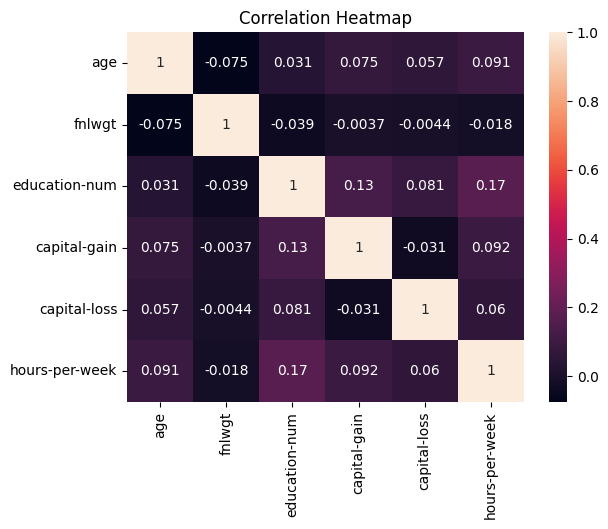

In [ ]:
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.drop('income', axis=1)), columns=df.drop('income', axis=1).columns)

In [ ]:
df_scaled

,age,fnlwgt,education-num,marital-status,relationship,race,sex,capital-gain,capital-loss,hours-per-week,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.376068,0.044131,0.800000,0.666667,0.2,1.00,1.0,0.021740,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.564103,0.048052,0.800000,0.333333,0.0,1.00,1.0,0.000000,0.0,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.358974,0.137581,0.533333,0.000000,0.2,1.00,1.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.615385,0.150486,0.400000,0.333333,0.0,0.50,1.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.188034,0.220635,0.800000,0.333333,1.0,0.50,0.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.376068,0.137428,0.800000,0.000000,0.2,1.00,0.0,0.000000,0.0,0.175,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48838,0.803419,0.209130,0.533333,1.000000,0.4,0.50,1.0,0.000000,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48839,0.358974,0.245379,0.800000,0.333333,0.0,1.00,1.0,0.000000,0.0,0.875,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48840,0.461538,0.048444,0.800000,0.000000,0.6,0.25,1.0,0.054551,0.0,0.375,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.decomposition import PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=[f'PC{i+1}' for i in range(pca.n_components_)])
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35
0,0.445289,-0.566327,-0.526133,-0.115366,-0.547154,0.139670,0.270862,0.830654,-0.739785,0.377053,...,0.485587,-0.140003,-0.152583,-0.071839,0.050617,0.002088,-0.037714,-0.118109,0.005687,0.008465
1,0.896986,-0.609167,-0.550376,-0.144281,-0.907774,0.194634,-0.199821,-0.038547,0.090793,0.411082,...,0.011867,0.008295,-0.123636,0.034950,0.099455,0.037122,-0.018611,0.038348,-0.033389,0.019316
2,0.192135,0.846934,0.065490,0.102768,0.080173,-0.196470,0.009760,-0.088298,-0.180459,0.136026,...,-0.073392,0.027403,-0.197230,0.001567,-0.022889,-0.023408,-0.013396,-0.036166,0.036288,-0.004911
3,0.252037,0.114706,0.402821,0.204414,0.045440,0.310708,-0.146692,-0.061661,-0.238520,-0.062820,...,-0.230820,-0.431848,-0.147144,-0.043668,0.060787,-0.182964,-0.098758,-0.023596,0.004988,0.051063
4,-0.642269,-0.758374,-0.592219,0.977662,0.237363,0.359202,-0.093525,0.154754,-0.016592,-0.408839,...,-0.043838,0.023833,-0.000125,-0.043120,-0.021101,-0.052406,-0.047314,0.072793,0.073969,-0.084189


In [ ]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.1106643  0.1039876  0.0796586  0.06913247 0.05384695 0.04032861
 0.03833143 0.03709388 0.03362412 0.03187185 0.02903497 0.02602837
 0.02357196 0.02345192 0.02186001 0.01811815 0.01747592 0.01625161
 0.01541366 0.01465742 0.0142633  0.01404146 0.01349895 0.01217741
 0.01189148 0.01149125 0.0106828  0.0100678  0.00983001 0.0088158
 0.00770286 0.00642391 0.00622884 0.00594269 0.00526419]


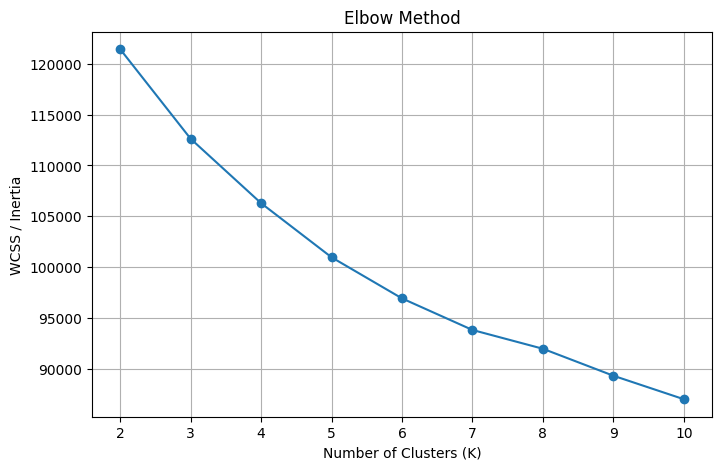

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')
plt.grid()
plt.show()

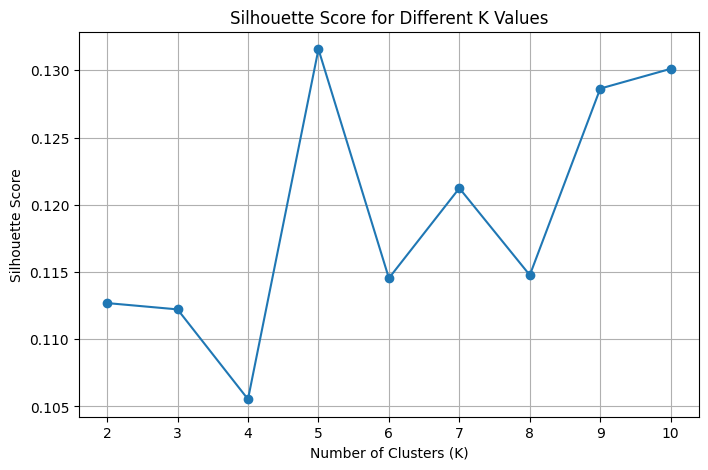

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_pca)

    score = silhouette_score(df_pca, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.grid()
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(df_pca)

df_pca['Cluster'] = cluster_labels

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC27,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,Cluster
0,0.445289,-0.566327,-0.526133,-0.115366,-0.547154,0.139670,0.270862,0.830654,-0.739785,0.377053,...,-0.140003,-0.152583,-0.071839,0.050617,0.002088,-0.037714,-0.118109,0.005687,0.008465,2
1,0.896986,-0.609167,-0.550376,-0.144281,-0.907774,0.194634,-0.199821,-0.038547,0.090793,0.411082,...,0.008295,-0.123636,0.034950,0.099455,0.037122,-0.018611,0.038348,-0.033389,0.019316,2
2,0.192135,0.846934,0.065490,0.102768,0.080173,-0.196470,0.009760,-0.088298,-0.180459,0.136026,...,0.027403,-0.197230,0.001567,-0.022889,-0.023408,-0.013396,-0.036166,0.036288,-0.004911,3
3,0.252037,0.114706,0.402821,0.204414,0.045440,0.310708,-0.146692,-0.061661,-0.238520,-0.062820,...,-0.431848,-0.147144,-0.043668,0.060787,-0.182964,-0.098758,-0.023596,0.004988,0.051063,0
4,-0.642269,-0.758374,-0.592219,0.977662,0.237363,0.359202,-0.093525,0.154754,-0.016592,-0.408839,...,0.023833,-0.000125,-0.043120,-0.021101,-0.052406,-0.047314,0.072793,0.073969,-0.084189,2


In [ ]:
df_pca['Cluster'].value_counts().sort_index()

,count
Cluster,
0,9783
1,9476
2,8017
3,10688
4,10878


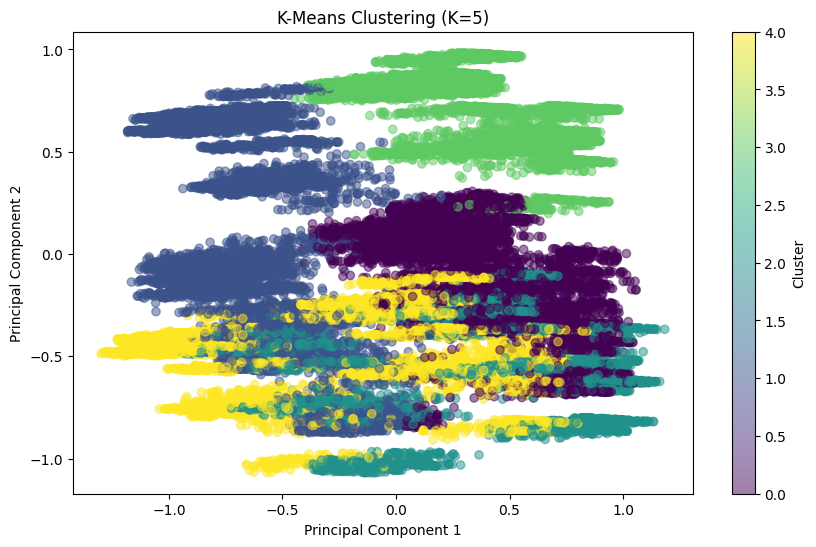

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=df_pca['Cluster'],
    cmap='viridis',
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (K=5)')

plt.colorbar(label='Cluster')

plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Use only PCA feature columns
pca_features = df_pca.drop(columns=['Cluster'], errors='ignore')

# Take a sample to avoid memory crash
sample_data = pca_features.sample(
    n=5000,
    random_state=42
)

# Agglomerative Clustering
agg = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

agg_labels = agg.fit_predict(sample_data)

# Store cluster labels
sample_data = sample_data.copy()
sample_data['Agg_Cluster'] = agg_labels

# Check cluster counts
print(sample_data['Agg_Cluster'].value_counts().sort_index())

Agg_Cluster
0    2452
1    1008
2     663
3     437
4     440
Name: count, dtype: int64


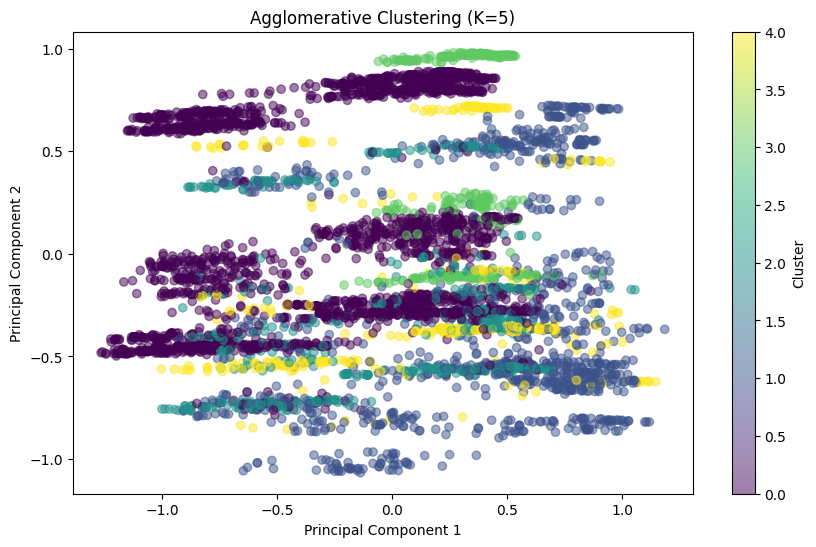

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    sample_data['PC1'],
    sample_data['PC2'],
    c=sample_data['Agg_Cluster'],
    cmap='viridis',
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering (K=5)')

plt.colorbar(label='Cluster')

plt.show()

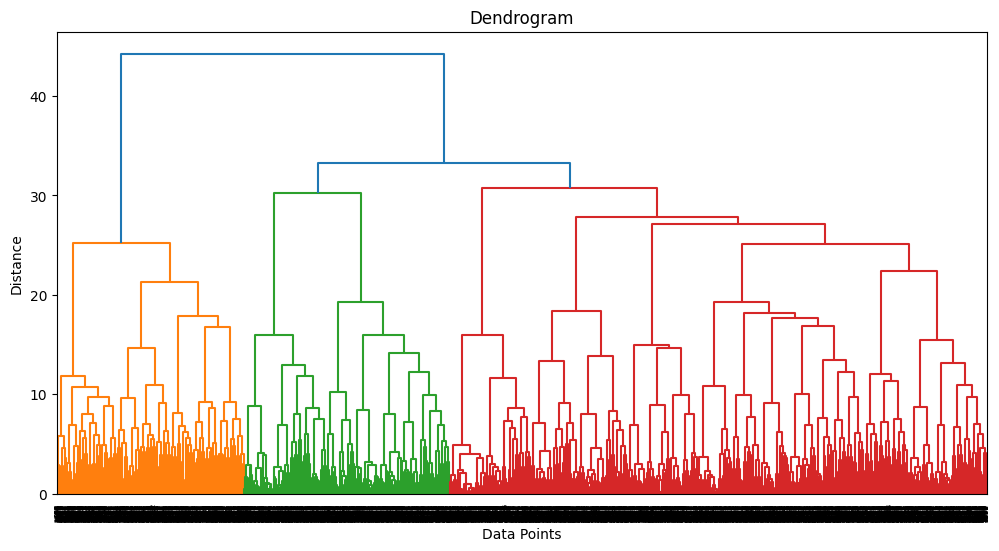

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Use a sample because the dataset is large
sample = sample_data.drop(columns='Agg_Cluster', errors='ignore')

mergings = linkage(sample, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(mergings)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [ ]:
ac_obj = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

ac_clusters = ac_obj.fit_predict(sample)

print("Agglomerative clustering completed.")

Agglomerative clustering completed.


In [ ]:
print("Agglomerative Silhouette Score:",
      round(silhouette_score(sample, ac_clusters), 4))

Agglomerative Silhouette Score: 0.0998


In [ ]:
df['kmeans_cluster'] = cluster_labels
df.groupby('kmeans_cluster')[num_cols].mean().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
kmeans_cluster,,,,,,
0,40.94,193823.49,9.73,2057.46,108.92,42.11
1,38.49,185824.02,9.27,591.68,61.66,38.81
2,38.82,188437.60,13.00,1764.32,124.90,42.49
3,39.01,189835.03,9.00,629.97,76.79,42.00
4,35.72,190004.69,10.00,559.96,73.72,40.42


In [ ]:
for cluster in sorted(df['kmeans_cluster'].unique()):

    temp = df[df['kmeans_cluster'] == cluster]

    print("\nCluster:", cluster)
    print("Average age:", round(temp['age'].mean(), 2))
    print("Average hours:", round(temp['hours-per-week'].mean(), 2))

    # Handle one-hot encoded categorical columns by finding the most frequent category
    # based on the sum of the one-hot encoded columns within the cluster.
    one_hot_features_to_describe = ['education', 'workclass', 'occupation']

    for original_cat_col in one_hot_features_to_describe:
        # Get all columns that start with the original category name
        matching_cols = [col for col in temp.columns if col.startswith(original_cat_col + '_')]

        if matching_cols:
            # Find the one-hot encoded column with the highest sum for the current cluster
            most_frequent_oh_col = temp[matching_cols].sum().idxmax()

            # Extract the actual category name
            category_value = most_frequent_oh_col.replace(original_cat_col + '_', '')
            print(f"{original_cat_col.capitalize()}:", category_value)

    # For label-encoded columns, directly use .mode().
    # Note: These will output numerical labels, not the original string categories.
    print("Marital status:", temp['marital-status'].mode()[0])
    print("Relationship:", temp['relationship'].mode()[0])
    print("Race:", temp['race'].mode()[0])
    print("Sex:", temp['sex'].mode()[0])


Cluster: 0
Average age: 40.94
Average hours: 42.11
Education: Masters
Workclass: Private
Occupation: Prof-specialty
Marital status: 2
Relationship: 0
Race: 4
Sex: 1

Cluster: 1
Average age: 38.49
Average hours: 38.81
Education: HS-grad
Workclass: Private
Occupation: Adm-clerical
Marital status: 4
Relationship: 1
Race: 4
Sex: 0

Cluster: 2
Average age: 38.82
Average hours: 42.49
Education: Bachelors
Workclass: Private
Occupation: Prof-specialty
Marital status: 2
Relationship: 0
Race: 4
Sex: 1

Cluster: 3
Average age: 39.01
Average hours: 42.0
Education: HS-grad
Workclass: Private
Occupation: Craft-repair
Marital status: 2
Relationship: 0
Race: 4
Sex: 1

Cluster: 4
Average age: 35.72
Average hours: 40.42
Education: Some-college
Workclass: Private
Occupation: Adm-clerical
Marital status: 4
Relationship: 0
Race: 4
Sex: 1


In [ ]:
income_cluster = pd.crosstab(
    df['kmeans_cluster'],
    df['income'],
    normalize='index'
).round(2)

income_cluster

income,<=50K,<=50K.,>50K,>50K.
kmeans_cluster,,,,
0,0.44,0.23,0.22,0.11
1,0.60,0.30,0.07,0.03
2,0.39,0.20,0.28,0.14
3,0.53,0.27,0.14,0.07
4,0.54,0.27,0.13,0.06


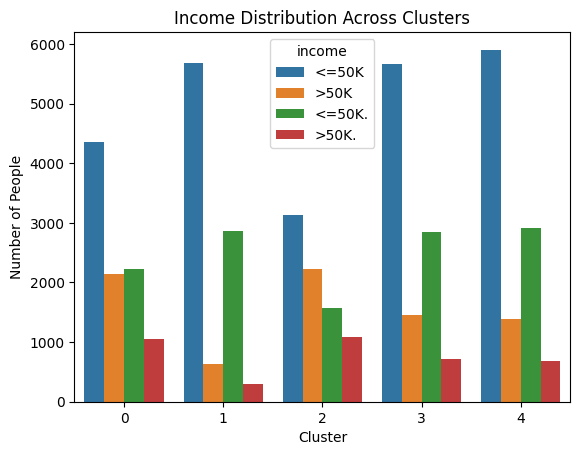

In [ ]:
sns.countplot(
    data=df,
    x='kmeans_cluster',
    hue='income'
)

plt.title("Income Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of People")

plt.show()